In [1]:
import numpy as np  
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer
from sklearn.preprocessing import TargetEncoder
from sklearn import preprocessing
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.ensemble import GradientBoostingRegressor
!pip install xgboost
from xgboost import XGBRegressor 

In [2]:
#CARGO EL CSV
airbnb_practica = pd.read_csv("airbnb-listings-extract.csv", engine='python', sep=None)

#DOY VALOR 1 A LOS APARTAMENTOS QUE TENGAN PISCINA Y AIRE ACONDICIONADO, A LOS DEMÁS 0.
#FILTRADO QUE ME HE INVENTADO POR DAR VALOR A ESA COLUMNA.
def categorizar(amenit):
    if pd.isna(amenit):
        return 0
    return int("Air conditioning" in amenit and "Pool" in amenit)
airbnb_practica['Amenities'] = airbnb_practica['Amenities'].apply(categorizar)

#HAGO UN PRIMER BARRIDO DE TODAS LAS COLUMNAS Y SELECCIONO LAS QUE TIENEN VALOR PREDICTIVO, ELIMINANDO INFORMACIÓN NO IMPORTANTE.
columnas_ok_practica = ['Neighbourhood Cleansed','City', 'Country', 'Property Type', 'Room Type', 'Accommodates', 'Bathrooms', 'Price', 'Security Deposit', 'Cleaning Fee',
                         'Guests Included','Extra People', 'Amenities', 'Availability 365', 'Review Scores Rating']
airbnb_practica_v2 = airbnb_practica[columnas_ok_practica]

#COLOCO LA COLUMNA PRICE EN LA PRIMERA COLUMNA PARA QUE SEA MÁS CÓMODO.
cols = ['Price'] + [col for col in airbnb_practica_v2.columns if col != 'Price']
airbnb_practica_v2 = airbnb_practica_v2[cols]

#HAGO LA DIVISIÓN TRAIN/TEST Y CREO LOS DOS NUEVOS CSVs CON ESTA DIVISIÓN
train, test = train_test_split(airbnb_practica_v2, test_size=0.2, shuffle=True, random_state=0) #Estratificar¿?¿?
train.to_csv("airbnb_practica_train.csv", sep=';', decimal='.', index=False)
test.to_csv("airbnb_practica_test.csv", sep=';', decimal='.', index=False)

# 4_Cargamos el csv de train y hacemos el análisis exploratorio con él
airbnb_practica_train = pd.read_csv("airbnb_practica_train.csv", engine='python', sep=None)
airbnb_practica_test = pd.read_csv("airbnb_practica_test.csv", engine='python', sep=None)

In [3]:
#CARGO LA SELECCIÓN DE TRAIN Y HAGO LA EXPLORACIÓN DE DATOS
airbnb_practica_train = pd.read_csv("airbnb_practica_train.csv", engine='python', sep=None)

#EXISTEN COLUMNAS QUE NO TIENEN VALORES, HAGO UNA IMPUTACION USANDO KNNIMPUTER
columnas_imputacion = ["Bathrooms","Price","Security Deposit", "Cleaning Fee", "Review Scores Rating"]
imputer = KNNImputer(n_neighbors=15)
airbnb_practica_train[columnas_imputacion] = imputer.fit_transform(airbnb_practica_train[columnas_imputacion])

#Aquí filtré una serie de caracteres raros en la columna Madrid que me daban error a la hora de seguir con la práctica.
madrid_aliases = ['马德里', 'Мадрид', 'Madrид'] 
airbnb_practica_train['City'] = airbnb_practica_train['City'].replace(madrid_aliases, 'Madrid')

#Aquí rellené los nulos de City y Country con "Desconocido"
columnas_imputacion_2 = ['City', 'Country']
airbnb_practica_train[columnas_imputacion_2] = airbnb_practica_train[columnas_imputacion_2].fillna("Desconocido")

#Aquí utilicé target encoder ya que me pareció que podía dar un valor con más relevancia predictiva sobre el precio.
cat_cols = ['Neighbourhood Cleansed', 'City', 'Country', 'Property Type', 'Room Type']
target_encoder = TargetEncoder(smooth="auto", target_type="continuous")
airbnb_practica_train[cat_cols] = target_encoder.fit_transform(airbnb_practica_train[cat_cols], airbnb_practica_train['Price'])

#Aquí hice la eliminación de los outliers
airbnb_practica_train_no_outliers = airbnb_practica_train[airbnb_practica_train['Cleaning Fee'] <= 300]
airbnb_practica_train_no_outliers2 = airbnb_practica_train_no_outliers[airbnb_practica_train_no_outliers['Extra People'] <= 120]
airbnb_practica_train_no_outliers3 = airbnb_practica_train_no_outliers2[airbnb_practica_train_no_outliers2['Security Deposit'] <= 900]
airbnb_practica_train_final = airbnb_practica_train_no_outliers3[airbnb_practica_train_no_outliers3['Bathrooms'] <= 7]

In [4]:
#CARGO LA SELECCIÓN DE TEST Y APLICO TODO LO MODIFICADO EN TRAIN
airbnb_practica_test = pd.read_csv("airbnb_practica_test.csv", engine='python', sep=None)

#REPLICO todo lo hecho en train, con cuidado de solo utilizar transform para el KNNImputer y el TargetEncoder:
airbnb_practica_test[columnas_imputacion] = imputer.transform(airbnb_practica_test[columnas_imputacion])
airbnb_practica_test['City'] = airbnb_practica_test['City'].replace(madrid_aliases, 'Madrid')
airbnb_practica_test[columnas_imputacion_2] = airbnb_practica_test[columnas_imputacion_2].fillna("Desconocido")
airbnb_practica_test[cat_cols] = target_encoder.transform(airbnb_practica_test[cat_cols])
airbnb_practica_test = airbnb_practica_test[airbnb_practica_test['Cleaning Fee'] <= 300]
airbnb_practica_test = airbnb_practica_test[airbnb_practica_test['Extra People'] <= 120]
airbnb_practica_test = airbnb_practica_test[airbnb_practica_test['Security Deposit'] <= 900]
airbnb_practica_test = airbnb_practica_test[airbnb_practica_test['Bathrooms'] <= 7]

In [5]:
 # Dataset de train
data_train = airbnb_practica_train_final.values
y_train = data_train[:,0]     # nos quedamos con la 1ª columna, price
X_train = data_train[:,1:]      # nos quedamos con el resto

# Dataset de test
data_test = airbnb_practica_test.values
y_test = data_test[:,0]     # nos quedamos con la 1ª columna, price
X_test = data_test[:,1:]      # nos quedamos con el resto

# Escalamos (con los datos de train)
scaler = preprocessing.StandardScaler().fit(X_train)
XtrainScaled = scaler.transform(X_train)

# recordad que esta normalización/escalado la realizo con el scaler anterior, basado en los datos de training!
XtestScaled = scaler.transform(X_test)

print('Datos entrenamiento: ', XtrainScaled.shape)
print('Datos test: ', XtestScaled.shape)

Datos entrenamiento:  (11799, 14)
Datos test:  (2949, 14)


[INFO] DataFrames no encontrados en el namespace.
       Cargando y procesando desde CSV...

  Train procesado: (11799, 15)
  Test procesado:  (2956, 15)

Datos entrenamiento:  (11799, 14)
Datos test:           (2956, 14)
[INFO] feature_names no definido. Se usarán nombres genéricos.
Features (14): ['Feature_0', 'Feature_1', 'Feature_2', 'Feature_3', 'Feature_4', 'Feature_5', 'Feature_6', 'Feature_7', 'Feature_8', 'Feature_9', 'Feature_10', 'Feature_11', 'Feature_12', 'Feature_13']


  1. MODELOS LINEALES

Lasso y Ridge son regresiones lineales con regularización.
  · Lasso (L1): penaliza Σ|wᵢ| → puede poner coeficientes exactamente
    a 0 (selección de variables implícita). Útil si sospechas que
    muchas features son irrelevantes.
  · Ridge (L2): penaliza Σwᵢ² → reduce todos los coeficientes suavemente
    pero no los elimina. Mejor cuando todas las features contribuyen.

El hiperparámetro alpha controla la fuerza de la regularización:
  α → 0: sin regularización (puede overfit)
  

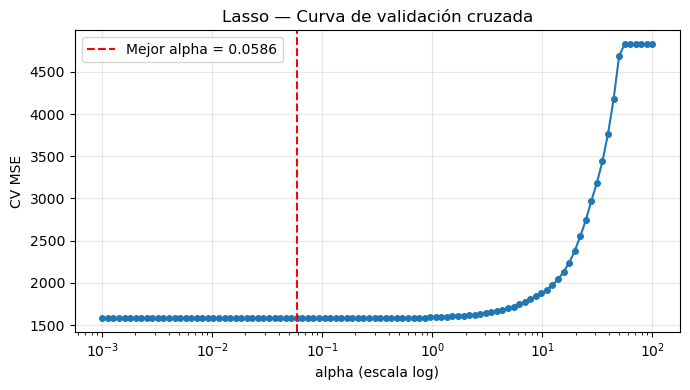


  INTERPRETACIÓN — Curva de validación Lasso:
  · Eje X: alpha en escala logarítmica (de débil a fuerte regularización).
  · Eje Y: MSE de validación cruzada (5-fold). Menor = mejor.
  · La curva desciende hasta un mínimo y luego sube:
    - Izquierda del mínimo: alpha demasiado pequeño → el modelo casi no
      está regularizado, puede memorizar ruido del train.
    - Derecha del mínimo: alpha demasiado grande → penalización excesiva,
      el modelo se vuelve demasiado simple (infraajuste).
  · La línea roja marca el alpha óptimo seleccionado por CV.
  · Si el mínimo es muy plano (meseta amplia), el modelo es robusto
    a la elección de alpha, lo cual es una buena señal.


────────────────────────────────────────────────────
  LASSO
  R²   → train: 0.6767  |  test: 0.6739  ✓  OK
  RMSE → train: 39.52  |  test: 42.14

  INTERPRETACIÓN DE MÉTRICAS — Lasso
  ┌─────────────────────────────────────────────────────────────┐
  │ R² Test = 0.6739  →  calidad moderada
  │   El modelo explic

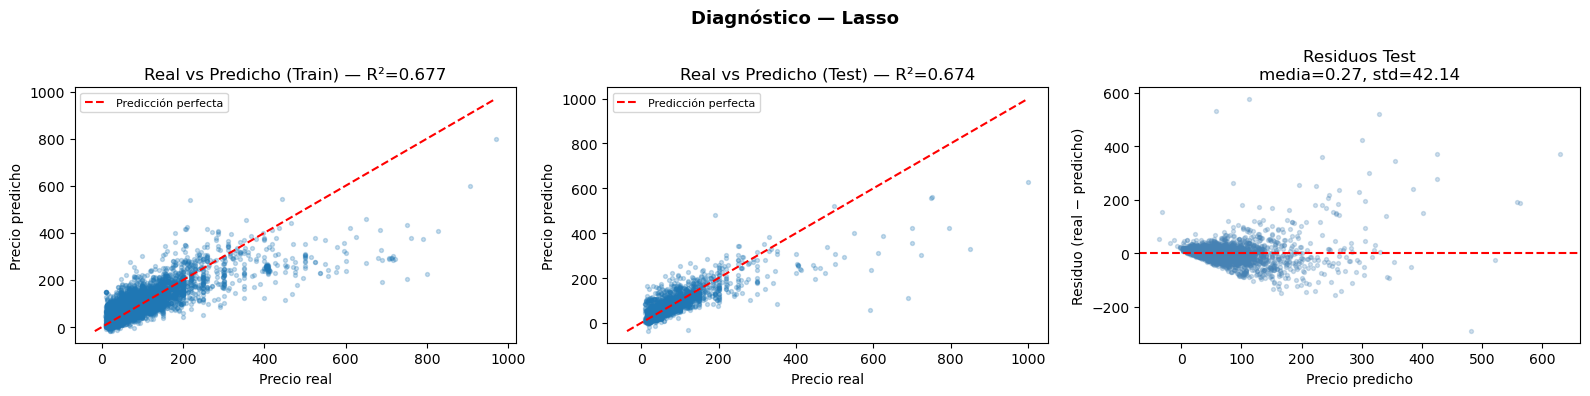


  INTERPRETACIÓN GRÁFICAS DIAGNÓSTICO — Lasso
  · Real vs Predicho (Train):  R²=0.677
    Muestra cómo de bien ajusta el modelo a sus propios datos de entrenamiento.
    Si los puntos están muy cerca de la diagonal roja, el modelo aprende bien
    el patrón. Si hay dispersión grande, incluso en train, el modelo tiene
    capacidad insuficiente (underfitting).

  · Real vs Predicho (Test):  R²=0.674
    Esta es la gráfica más importante: refleja el rendimiento REAL del modelo
    sobre datos que nunca ha visto. Buscar:
      - Nube compacta alrededor de la diagonal → modelo preciso.
      - Forma de abanico (más dispersión a precios altos) → el modelo
        predice peor los pisos caros, posiblemente por outliers o
        falta de features que capturen el lujo.
      - Puntos muy alejados de la diagonal → outliers que el modelo no predice bien.
    Gap de 0.003 → la diferencia entre train y test es aceptable.

  · Residuos Test  (media=42.14 €)
    Eje X: precio predicho. Eje Y: erro

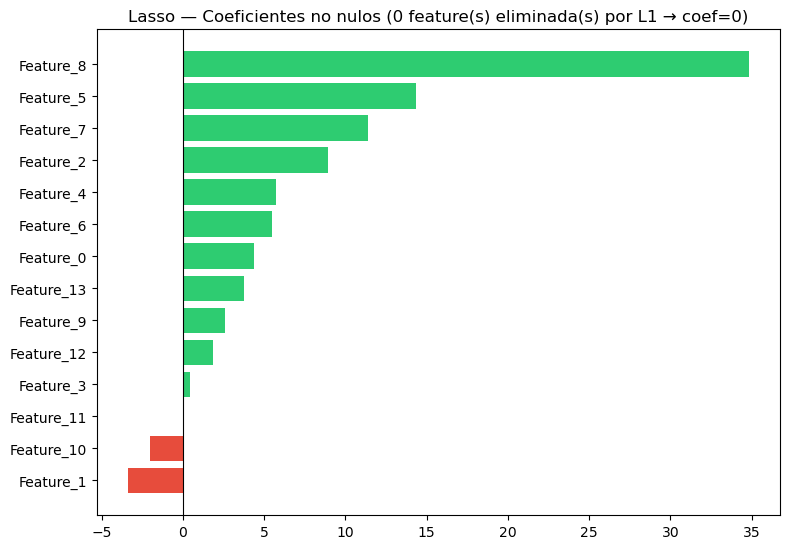


  INTERPRETACIÓN — Coeficientes Lasso:
  · Verde (coef > 0): la feature aumenta el precio predicho.
    Ejemplo: más habitaciones → precio más alto.
  · Rojo (coef < 0): la feature disminuye el precio predicho.
  · Coeficiente = 0 (eliminadas por L1): Lasso las considera redundantes
    o irrelevantes dado el resto de información. En este caso eliminó
    0 feature(s). Esto es selección de variables automática.
  · La magnitud del coeficiente indica el impacto: al estar los datos
    escalados (media=0, std=1), los coeficientes son comparables entre sí.
    Un coef de 10 significa que aumentar esa feature en 1 desviación
    estándar sube el precio predicho en 10 unidades.


>>> RIDGE
Mejor alpha: 28.48  |  CV MSE: 1581.74


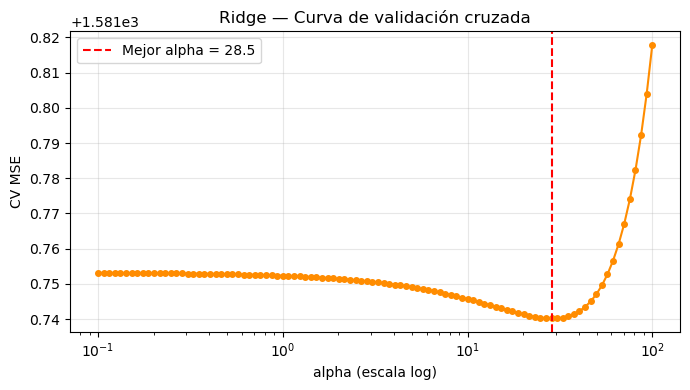


  INTERPRETACIÓN — Curva de validación Ridge:
  · Misma lectura que Lasso: buscar el mínimo del MSE CV.
  · Ridge suele tener una curva más suave que Lasso porque L2 reduce
    gradualmente los coeficientes en lugar de forzarlos a 0.
  · Si el alpha óptimo de Ridge es muy pequeño (cercano a 0), indica
    que los datos no necesitan mucha regularización y el modelo lineal
    ya generaliza bien por sí solo.
  · Si el alpha óptimo es muy grande, indica multicolinealidad fuerte
    entre las features (Ridge es especialmente útil en ese caso).


────────────────────────────────────────────────────
  RIDGE
  R²   → train: 0.6768  |  test: 0.6737  ✓  OK
  RMSE → train: 39.51  |  test: 42.15

  INTERPRETACIÓN DE MÉTRICAS — Ridge
  ┌─────────────────────────────────────────────────────────────┐
  │ R² Test = 0.6737  →  calidad moderada
  │   El modelo explica el 67.4% de la varianza del precio.
  │   El 32.6% restante se debe a factores no capturados
  │   (p.ej. calidad de fotos, descripción

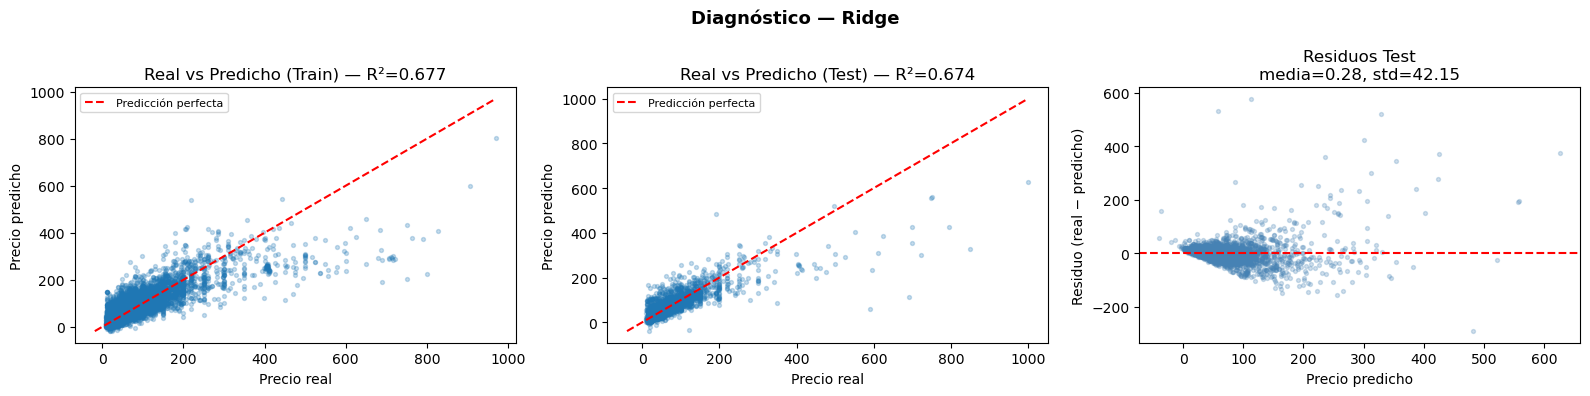


  INTERPRETACIÓN GRÁFICAS DIAGNÓSTICO — Ridge
  · Real vs Predicho (Train):  R²=0.677
    Muestra cómo de bien ajusta el modelo a sus propios datos de entrenamiento.
    Si los puntos están muy cerca de la diagonal roja, el modelo aprende bien
    el patrón. Si hay dispersión grande, incluso en train, el modelo tiene
    capacidad insuficiente (underfitting).

  · Real vs Predicho (Test):  R²=0.674
    Esta es la gráfica más importante: refleja el rendimiento REAL del modelo
    sobre datos que nunca ha visto. Buscar:
      - Nube compacta alrededor de la diagonal → modelo preciso.
      - Forma de abanico (más dispersión a precios altos) → el modelo
        predice peor los pisos caros, posiblemente por outliers o
        falta de features que capturen el lujo.
      - Puntos muy alejados de la diagonal → outliers que el modelo no predice bien.
    Gap de 0.003 → la diferencia entre train y test es aceptable.

  · Residuos Test  (media=42.15 €)
    Eje X: precio predicho. Eje Y: erro

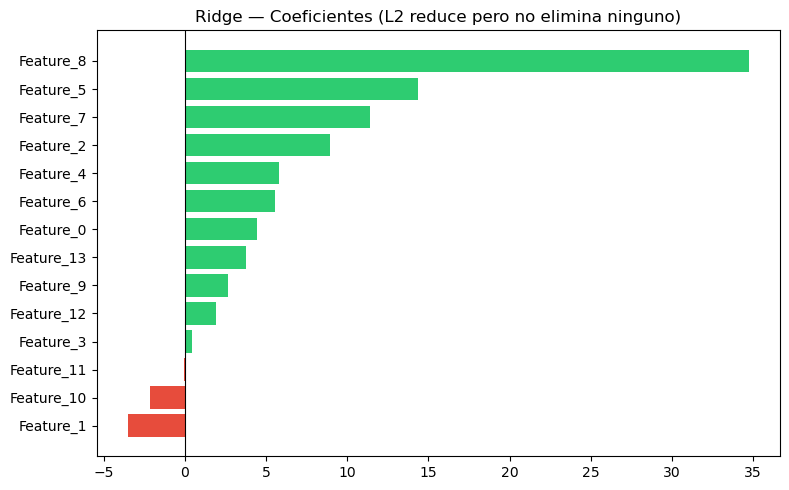


  INTERPRETACIÓN — Coeficientes Ridge:
  · A diferencia de Lasso, Ridge mantiene TODOS los coeficientes con valor.
  · Verde (positivo) → sube el precio | Rojo (negativo) → baja el precio.
  · Comparando con los coeficientes de Lasso:
    - Si una feature tiene coef grande en Ridge pero fue eliminada en Lasso,
      es una feature con información pero correlacionada con otras.
    - Si ambos modelos asignan importancia similar, la feature es robustamente
      relevante para predecir el precio.
  · Si un coeficiente es negativo y no tiene sentido económico (p.ej. más
    habitaciones → precio más bajo), puede indicar multicolinealidad o
    que el TargetEncoder ha capturado parte de esa información.


  2. ÁRBOLES DE DECISIÓN

Los árboles dividen el espacio de features en regiones haciendo
preguntas binarias (If-Else). Cada hoja predice la media de los
valores de entrenamiento que caen en esa región.

Hiperparámetros clave:
  · max_depth: profundidad máxima.
    Bajo → underfitting | 

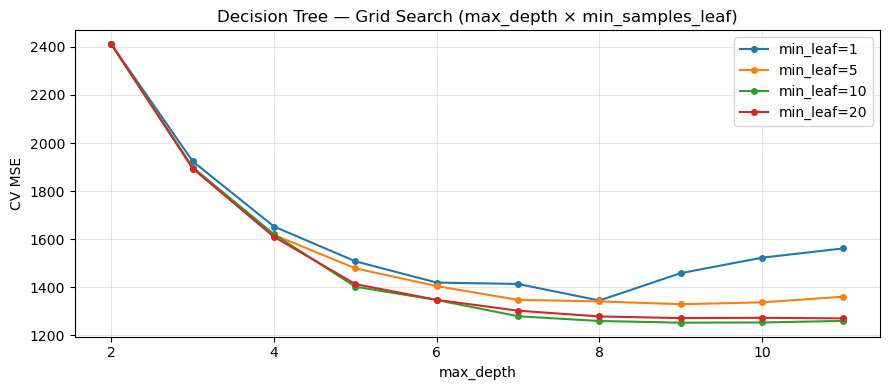


  INTERPRETACIÓN — Grid Search Decision Tree:
  · Cada línea representa un valor de min_samples_leaf.
  · Eje X: profundidad máxima del árbol. Eje Y: MSE CV (menor = mejor).
  · Patrón típico: el MSE baja rápido al principio (el árbol gana
    capacidad), luego se estabiliza o sube (empieza a memorizar).
  · El mínimo de cada línea indica la profundidad óptima para ese
    valor de min_samples_leaf.
  · Si la línea de min_leaf=1 (sin restricción) alcanza el mínimo
    antes que el resto y luego sube: clara señal de overfitting.
  · La línea con min_leaf más alto suele ser más plana: árbol más
    conservador, menos sensible a la profundidad.
  · Params elegidos: {'max_depth': 9, 'min_samples_leaf': 10}


────────────────────────────────────────────────────
  DECISION TREE
  R²   → train: 0.8258  |  test: 0.7061  ⚠  OVERFITTING
  RMSE → train: 29.01  |  test: 40.01

  INTERPRETACIÓN DE MÉTRICAS — Decision Tree
  ┌─────────────────────────────────────────────────────────────┐
  │ R² Tes

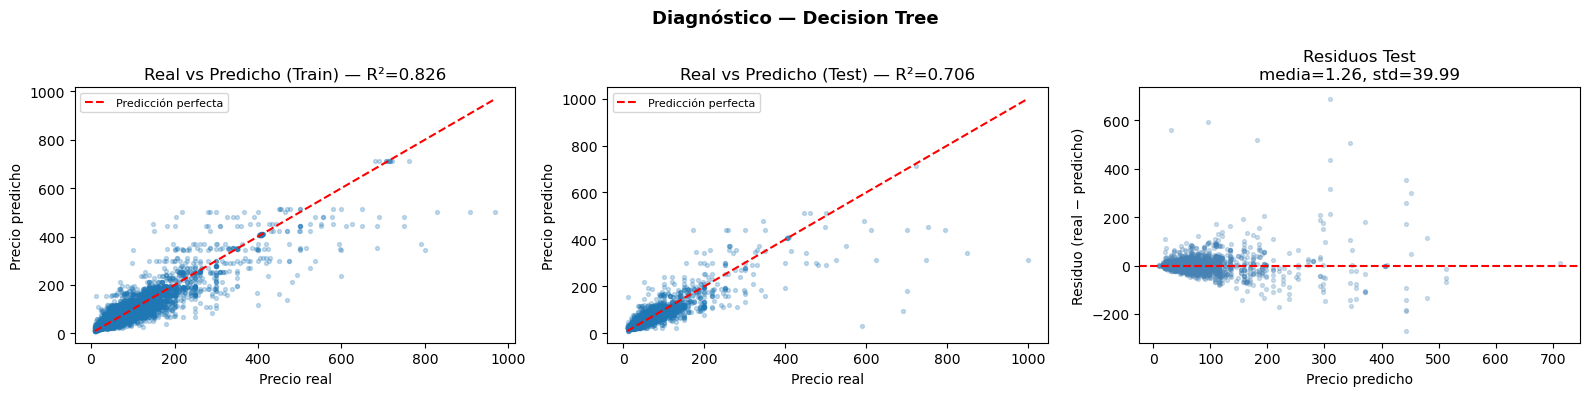


  INTERPRETACIÓN GRÁFICAS DIAGNÓSTICO — Decision Tree
  · Real vs Predicho (Train):  R²=0.826
    Muestra cómo de bien ajusta el modelo a sus propios datos de entrenamiento.
    Si los puntos están muy cerca de la diagonal roja, el modelo aprende bien
    el patrón. Si hay dispersión grande, incluso en train, el modelo tiene
    capacidad insuficiente (underfitting).

  · Real vs Predicho (Test):  R²=0.706
    Esta es la gráfica más importante: refleja el rendimiento REAL del modelo
    sobre datos que nunca ha visto. Buscar:
      - Nube compacta alrededor de la diagonal → modelo preciso.
      - Forma de abanico (más dispersión a precios altos) → el modelo
        predice peor los pisos caros, posiblemente por outliers o
        falta de features que capturen el lujo.
      - Puntos muy alejados de la diagonal → outliers que el modelo no predice bien.
    Gap de 0.120 → comparando train vs test se observa una caída de R² relevante.

  · Residuos Test  (media=40.01 €)
    Eje X: prec

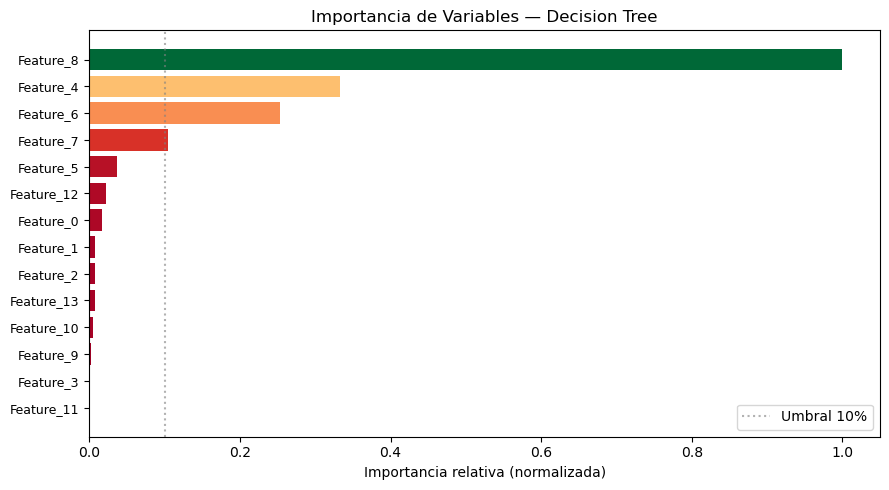


  INTERPRETACIÓN IMPORTANCIA DE VARIABLES — Decision Tree
  · Las 3 variables más influyentes: Feature_8, Feature_4, Feature_6
    Estas features concentran la mayor parte del poder predictivo del modelo.
    Son los factores que más determinan el precio en este dataset.

  · Variables por debajo del umbral 10%: Feature_0, Feature_1, Feature_2, Feature_3, Feature_5, Feature_9, Feature_10, Feature_11, Feature_12, Feature_13
    Tienen poca influencia. Podrías eliminarlas para simplificar el modelo
    sin perder apenas rendimiento (y reduciendo el riesgo de overfitting).

  · Nota metodológica: en árboles, la importancia mide cuánto reduce
    cada feature el error en los splits donde se usa. No implica
    causalidad: una variable puede ser importante porque correlaciona
    con otras, no porque cause el precio directamente.

>>> RANDOM FOREST
Ensemble de N árboles entrenados en bootstrap samples.
Diferencia clave vs Bagging: en cada split solo se evalúan max_features
features aleator

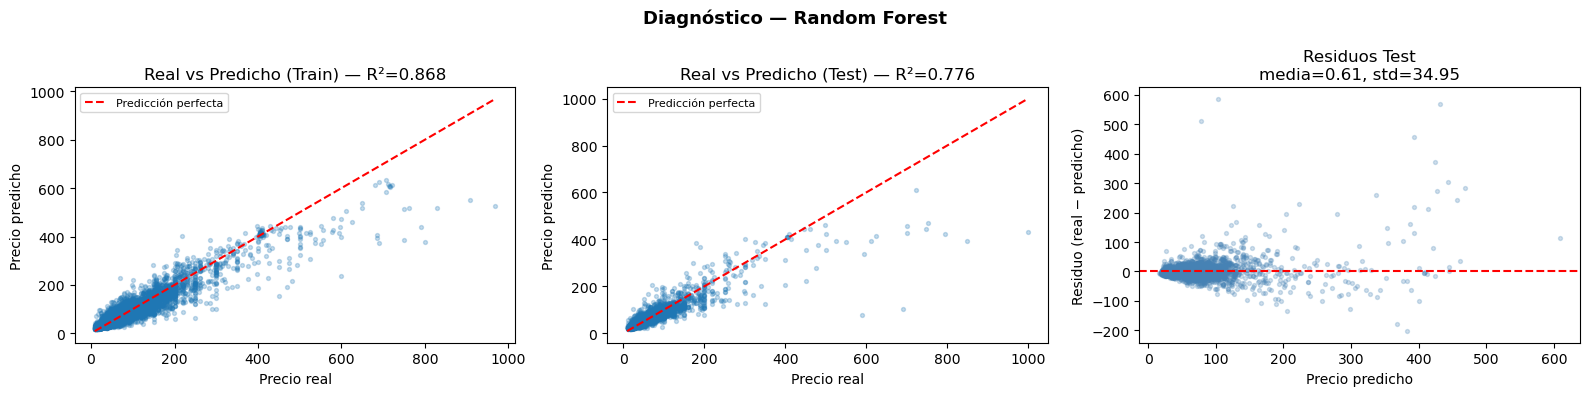


  INTERPRETACIÓN GRÁFICAS DIAGNÓSTICO — Random Forest
  · Real vs Predicho (Train):  R²=0.868
    Muestra cómo de bien ajusta el modelo a sus propios datos de entrenamiento.
    Si los puntos están muy cerca de la diagonal roja, el modelo aprende bien
    el patrón. Si hay dispersión grande, incluso en train, el modelo tiene
    capacidad insuficiente (underfitting).

  · Real vs Predicho (Test):  R²=0.776
    Esta es la gráfica más importante: refleja el rendimiento REAL del modelo
    sobre datos que nunca ha visto. Buscar:
      - Nube compacta alrededor de la diagonal → modelo preciso.
      - Forma de abanico (más dispersión a precios altos) → el modelo
        predice peor los pisos caros, posiblemente por outliers o
        falta de features que capturen el lujo.
      - Puntos muy alejados de la diagonal → outliers que el modelo no predice bien.
    Gap de 0.092 → la diferencia entre train y test es aceptable.

  · Residuos Test  (media=34.96 €)
    Eje X: precio predicho. Eje

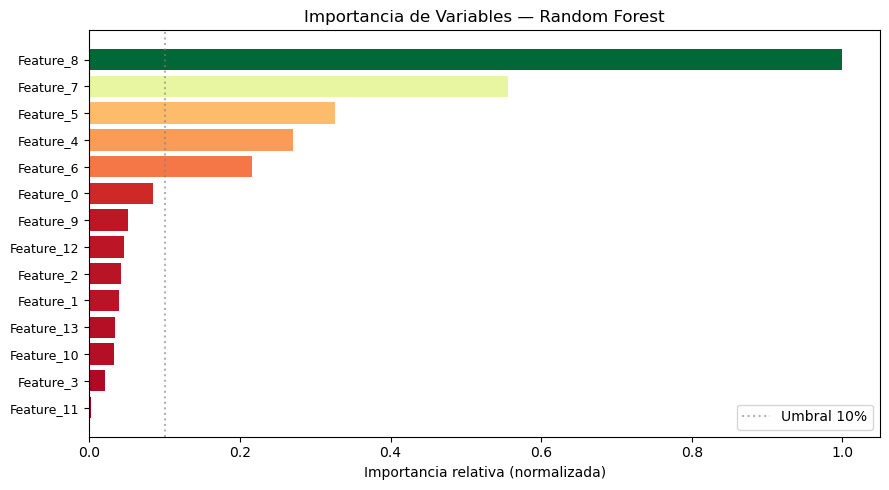


  INTERPRETACIÓN IMPORTANCIA DE VARIABLES — Random Forest
  · Las 3 variables más influyentes: Feature_8, Feature_7, Feature_5
    Estas features concentran la mayor parte del poder predictivo del modelo.
    Son los factores que más determinan el precio en este dataset.

  · Variables por debajo del umbral 10%: Feature_0, Feature_1, Feature_2, Feature_3, Feature_9, Feature_10, Feature_11, Feature_12, Feature_13
    Tienen poca influencia. Podrías eliminarlas para simplificar el modelo
    sin perder apenas rendimiento (y reduciendo el riesgo de overfitting).

  · Nota metodológica: en árboles, la importancia mide cuánto reduce
    cada feature el error en los splits donde se usa. No implica
    causalidad: una variable puede ser importante porque correlaciona
    con otras, no porque cause el precio directamente.

>>> BAGGING REGRESSOR
Bagging (Bootstrap Aggregating): N árboles en bootstrap samples,
pero cada árbol evalúa TODAS las features en cada split (a diferencia de RF).
Útil pa

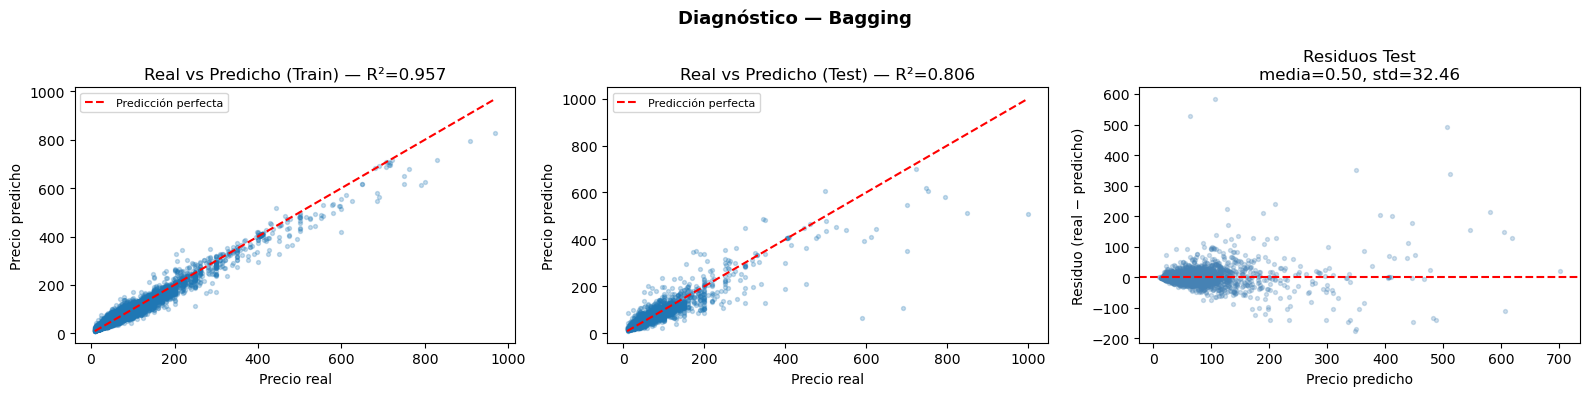


  INTERPRETACIÓN GRÁFICAS DIAGNÓSTICO — Bagging
  · Real vs Predicho (Train):  R²=0.957
    Muestra cómo de bien ajusta el modelo a sus propios datos de entrenamiento.
    Si los puntos están muy cerca de la diagonal roja, el modelo aprende bien
    el patrón. Si hay dispersión grande, incluso en train, el modelo tiene
    capacidad insuficiente (underfitting).

  · Real vs Predicho (Test):  R²=0.806
    Esta es la gráfica más importante: refleja el rendimiento REAL del modelo
    sobre datos que nunca ha visto. Buscar:
      - Nube compacta alrededor de la diagonal → modelo preciso.
      - Forma de abanico (más dispersión a precios altos) → el modelo
        predice peor los pisos caros, posiblemente por outliers o
        falta de features que capturen el lujo.
      - Puntos muy alejados de la diagonal → outliers que el modelo no predice bien.
    Gap de 0.151 → comparando train vs test se observa una caída de R² relevante.

  · Residuos Test  (media=32.47 €)
    Eje X: precio pre

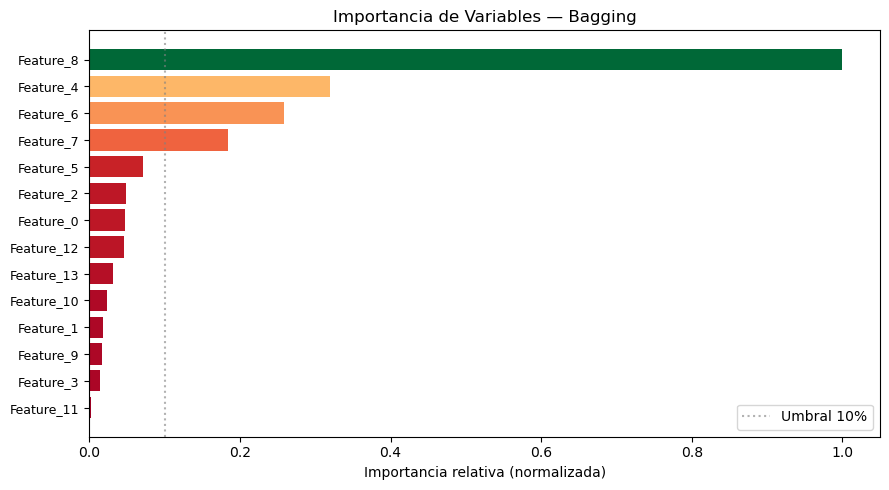


  INTERPRETACIÓN IMPORTANCIA DE VARIABLES — Bagging
  · Las 3 variables más influyentes: Feature_8, Feature_4, Feature_6
    Estas features concentran la mayor parte del poder predictivo del modelo.
    Son los factores que más determinan el precio en este dataset.

  · Variables por debajo del umbral 10%: Feature_0, Feature_1, Feature_2, Feature_3, Feature_5, Feature_9, Feature_10, Feature_11, Feature_12, Feature_13
    Tienen poca influencia. Podrías eliminarlas para simplificar el modelo
    sin perder apenas rendimiento (y reduciendo el riesgo de overfitting).

  · Nota metodológica: en árboles, la importancia mide cuánto reduce
    cada feature el error en los splits donde se usa. No implica
    causalidad: una variable puede ser importante porque correlaciona
    con otras, no porque cause el precio directamente.

  NOTA COMPARATIVA — Bagging vs Random Forest:
  · Si Bagging supera a RF: las features tienen información complementaria
    y no hay problema de dominancia (una feat

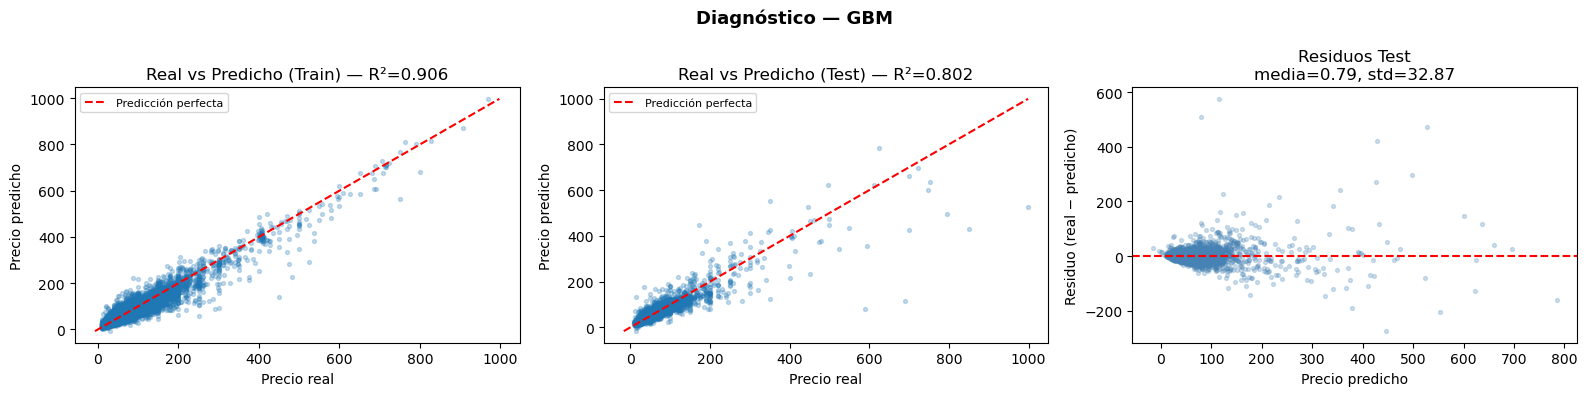


  INTERPRETACIÓN GRÁFICAS DIAGNÓSTICO — GBM
  · Real vs Predicho (Train):  R²=0.906
    Muestra cómo de bien ajusta el modelo a sus propios datos de entrenamiento.
    Si los puntos están muy cerca de la diagonal roja, el modelo aprende bien
    el patrón. Si hay dispersión grande, incluso en train, el modelo tiene
    capacidad insuficiente (underfitting).

  · Real vs Predicho (Test):  R²=0.802
    Esta es la gráfica más importante: refleja el rendimiento REAL del modelo
    sobre datos que nunca ha visto. Buscar:
      - Nube compacta alrededor de la diagonal → modelo preciso.
      - Forma de abanico (más dispersión a precios altos) → el modelo
        predice peor los pisos caros, posiblemente por outliers o
        falta de features que capturen el lujo.
      - Puntos muy alejados de la diagonal → outliers que el modelo no predice bien.
    Gap de 0.104 → comparando train vs test se observa una caída de R² relevante.

  · Residuos Test  (media=32.88 €)
    Eje X: precio predich

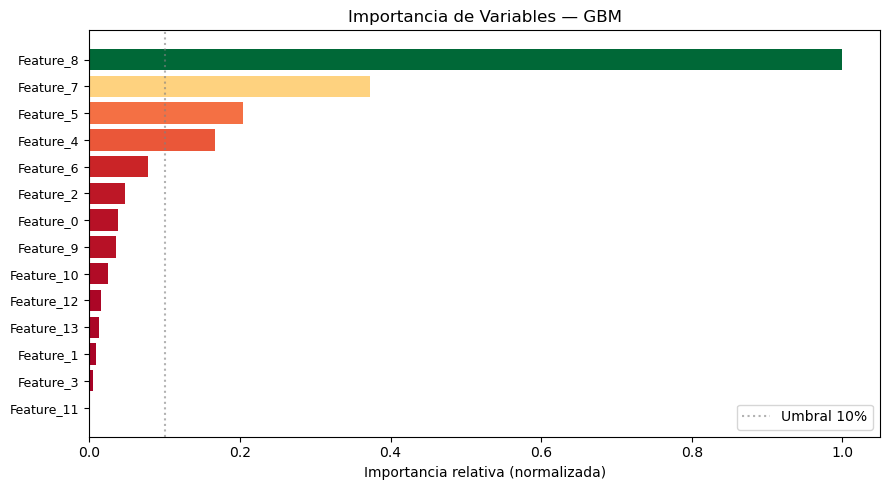


  INTERPRETACIÓN IMPORTANCIA DE VARIABLES — GBM
  · Las 3 variables más influyentes: Feature_8, Feature_7, Feature_5
    Estas features concentran la mayor parte del poder predictivo del modelo.
    Son los factores que más determinan el precio en este dataset.

  · Variables por debajo del umbral 10%: Feature_0, Feature_1, Feature_2, Feature_3, Feature_6, Feature_9, Feature_10, Feature_11, Feature_12, Feature_13
    Tienen poca influencia. Podrías eliminarlas para simplificar el modelo
    sin perder apenas rendimiento (y reduciendo el riesgo de overfitting).

  · Nota metodológica: en árboles, la importancia mide cuánto reduce
    cada feature el error en los splits donde se usa. No implica
    causalidad: una variable puede ser importante porque correlaciona
    con otras, no porque cause el precio directamente.


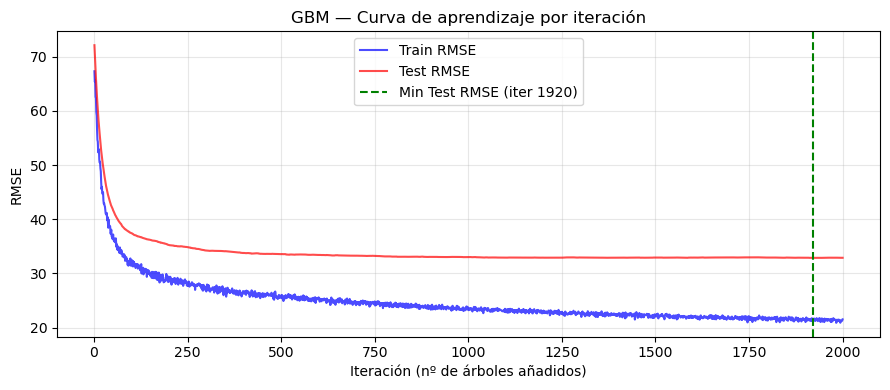


  INTERPRETACIÓN — Curva de deviance GBM:
  · Línea azul (Train RMSE): el error en entrenamiento siempre baja
    con más árboles. El modelo aprende cada vez más.
  · Línea roja (Test RMSE): baja al principio pero puede estabilizarse
    o subir después del mínimo → ahí empieza el overfitting.
  · Línea verde: iteración óptima = 1920 (mínimo RMSE en test).
  · El modelo fue entrenado con 2000 árboles, pero el
    mínimo real en test es a los 1920 árboles.
  · ⚠ Se usaron 80 árboles de más. Aplicar early stopping
    con n_estimators=1920 reduciría el tiempo de entrenamiento
    sin impacto relevante en rendimiento.


>>> XGBOOST
Implementación optimizada de Gradient Boosting.
Ventajas sobre sklearn GBM:
  · Más rápido (paralelización interna)
  · Regularización L1 (reg_alpha) y L2 (reg_lambda) nativa → menos overfitting
  · colsample_bytree: fracción de features por árbol (como max_features en RF)
  · Mejor manejo de valores faltantes

Fitting 3 folds for each of 16 candidates, totall

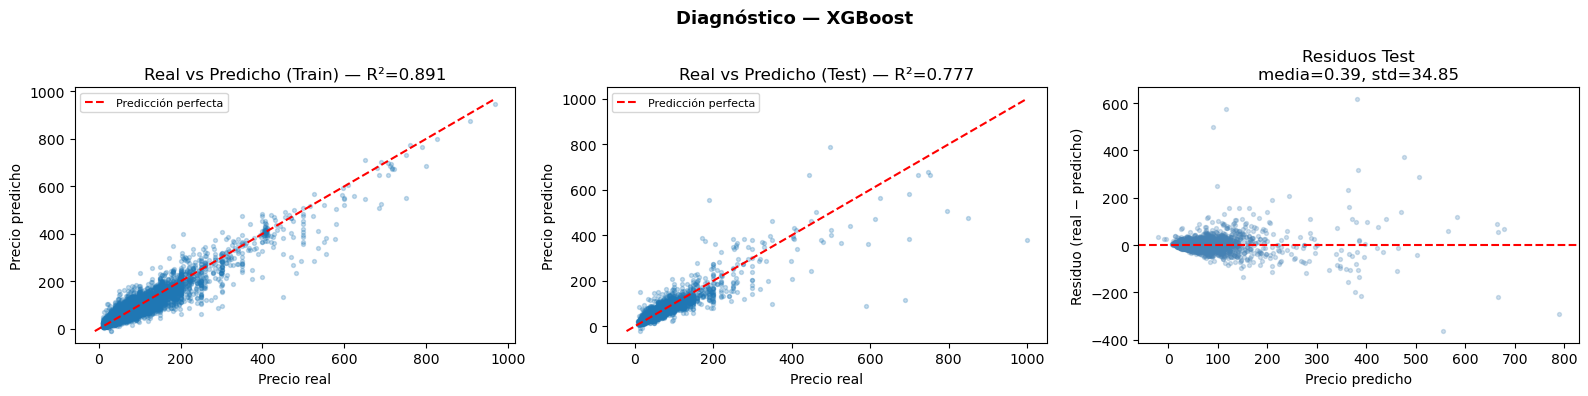


  INTERPRETACIÓN GRÁFICAS DIAGNÓSTICO — XGBoost
  · Real vs Predicho (Train):  R²=0.891
    Muestra cómo de bien ajusta el modelo a sus propios datos de entrenamiento.
    Si los puntos están muy cerca de la diagonal roja, el modelo aprende bien
    el patrón. Si hay dispersión grande, incluso en train, el modelo tiene
    capacidad insuficiente (underfitting).

  · Real vs Predicho (Test):  R²=0.777
    Esta es la gráfica más importante: refleja el rendimiento REAL del modelo
    sobre datos que nunca ha visto. Buscar:
      - Nube compacta alrededor de la diagonal → modelo preciso.
      - Forma de abanico (más dispersión a precios altos) → el modelo
        predice peor los pisos caros, posiblemente por outliers o
        falta de features que capturen el lujo.
      - Puntos muy alejados de la diagonal → outliers que el modelo no predice bien.
    Gap de 0.114 → comparando train vs test se observa una caída de R² relevante.

  · Residuos Test  (media=34.86 €)
    Eje X: precio pre

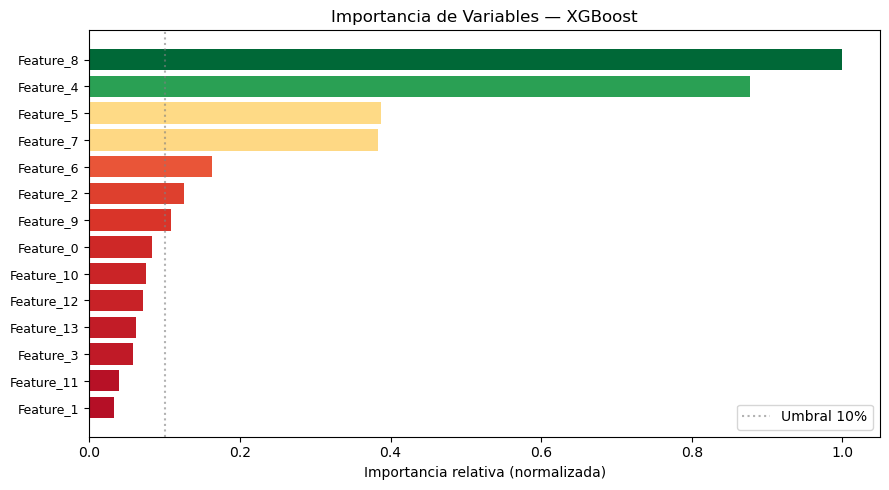


  INTERPRETACIÓN IMPORTANCIA DE VARIABLES — XGBoost
  · Las 3 variables más influyentes: Feature_8, Feature_4, Feature_5
    Estas features concentran la mayor parte del poder predictivo del modelo.
    Son los factores que más determinan el precio en este dataset.

  · Variables por debajo del umbral 10%: Feature_0, Feature_1, Feature_3, Feature_10, Feature_11, Feature_12, Feature_13
    Tienen poca influencia. Podrías eliminarlas para simplificar el modelo
    sin perder apenas rendimiento (y reduciendo el riesgo de overfitting).

  · Nota metodológica: en árboles, la importancia mide cuánto reduce
    cada feature el error en los splits donde se usa. No implica
    causalidad: una variable puede ser importante porque correlaciona
    con otras, no porque cause el precio directamente.

  4. SUPPORT VECTOR REGRESSION (SVR)

SVR busca una función que prediga dentro de un margen epsilon (ε-tube).
Los puntos fuera del margen son los 'vectores soporte' que definen el modelo.
Con kernel R

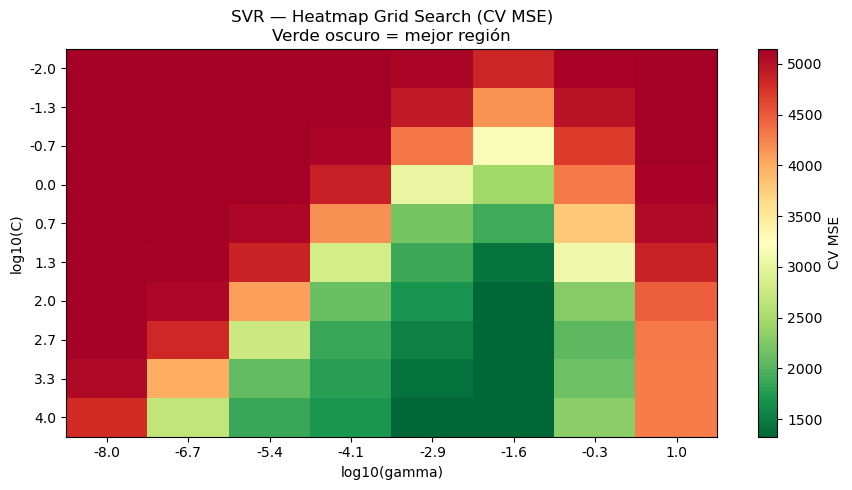


  INTERPRETACIÓN — Heatmap SVR (C vs gamma):
  · Cada celda es una combinación de C y gamma. Color verde oscuro = menor MSE.
  · La región óptima se ve claramente: C=4.6e+02,
    gamma=0.027
    (log10: C=2.7, gamma=-1.6)
  · Patrones típicos a observar:
    - Franja horizontal verde: C es determinante, gamma importa poco.
    - Franja vertical verde: gamma es el factor clave.
    - Isla verde en el centro: ambos parámetros importan y el modelo
      es sensible a su combinación exacta.
    - Si el verde está en la esquina inferior-izquierda (C bajo, gamma bajo):
      el kernel RBF se comporta casi como un modelo lineal.
    - Si está en la esquina superior-derecha: modelo muy no-lineal y complejo.
  · Si la región verde es pequeña (pocas celdas), el modelo es muy sensible
    a los hiperparámetros. Considerar un grid más fino en esa zona.


────────────────────────────────────────────────────
  SVR
  R²   → train: 0.8695  |  test: 0.6910  ⚠  OVERFITTING
  RMSE → train: 25.11  |  tes

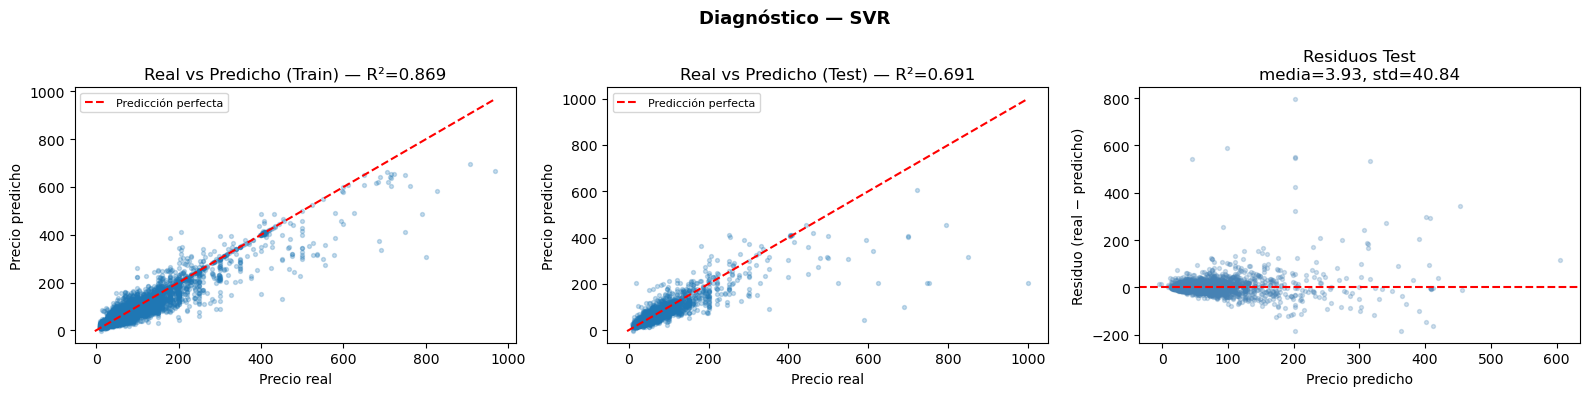


  INTERPRETACIÓN GRÁFICAS DIAGNÓSTICO — SVR
  · Real vs Predicho (Train):  R²=0.869
    Muestra cómo de bien ajusta el modelo a sus propios datos de entrenamiento.
    Si los puntos están muy cerca de la diagonal roja, el modelo aprende bien
    el patrón. Si hay dispersión grande, incluso en train, el modelo tiene
    capacidad insuficiente (underfitting).

  · Real vs Predicho (Test):  R²=0.691
    Esta es la gráfica más importante: refleja el rendimiento REAL del modelo
    sobre datos que nunca ha visto. Buscar:
      - Nube compacta alrededor de la diagonal → modelo preciso.
      - Forma de abanico (más dispersión a precios altos) → el modelo
        predice peor los pisos caros, posiblemente por outliers o
        falta de features que capturen el lujo.
      - Puntos muy alejados de la diagonal → outliers que el modelo no predice bien.
    Gap de 0.179 → comparando train vs test se observa una caída de R² relevante.

  · Residuos Test  (media=41.03 €)
    Eje X: precio predich

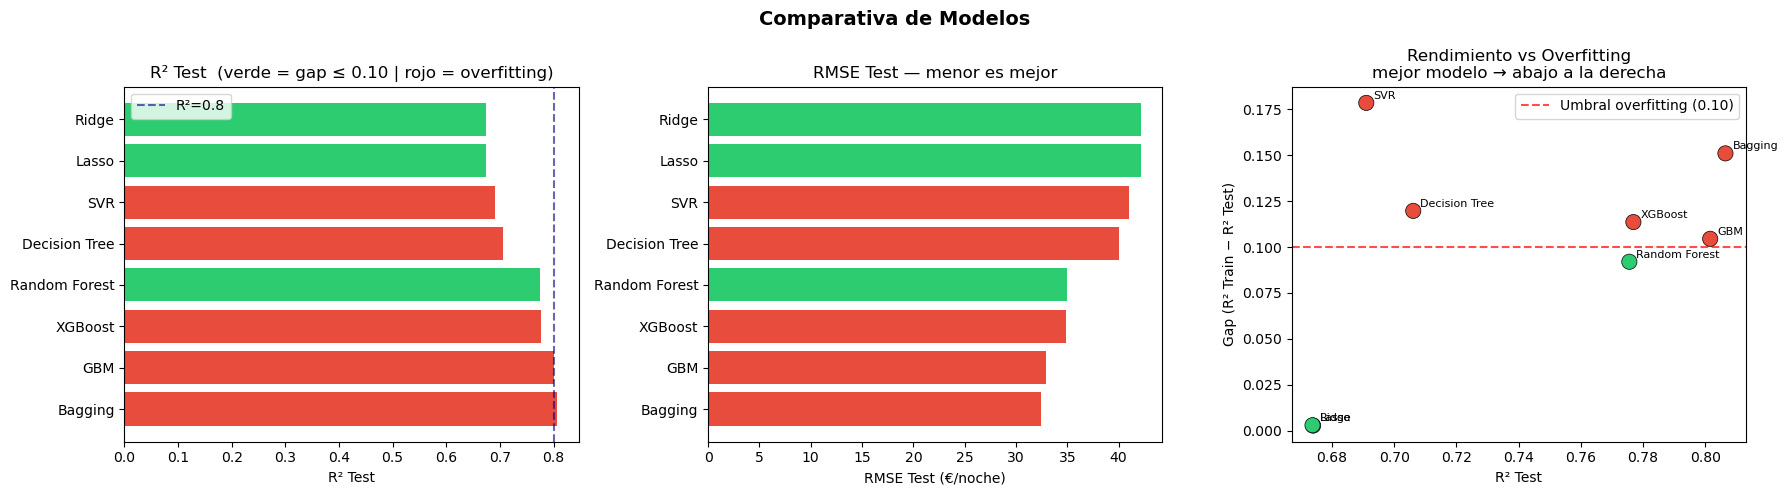


  INTERPRETACIÓN — Gráficas comparativas:
  · Gráfica izquierda (R² Test): muestra el rendimiento real de cada modelo.
    La línea azul punteada marca R²=0.8, un umbral razonable de 'buen modelo'
    para predicción de precios. Barras verdes = gap bajo (generaliza bien).
    Barras rojas = overfitting notable.

  · Gráfica central (RMSE Test): el error en euros/noche de cada modelo.
    Directamente interpretable: si RMSE=40, el modelo se equivoca de media
    40€ por noche en sus predicciones sobre datos nuevos.

  · Gráfica derecha (Rendimiento vs Overfitting):
    El eje X es el R² test (queremos que sea alto → a la derecha).
    El eje Y es el gap train-test (queremos que sea bajo → abajo).
    El modelo ideal está en la esquina inferior-derecha: alto rendimiento
    Y baja diferencia train-test. Modelos en la esquina superior-derecha
    son buenos pero memorizan demasiado el train.

  Resumen:
  · Mejor modelo por R² Test: Bagging (R²=0.8065, RMSE=32.47€)
  · Modelos con overfi

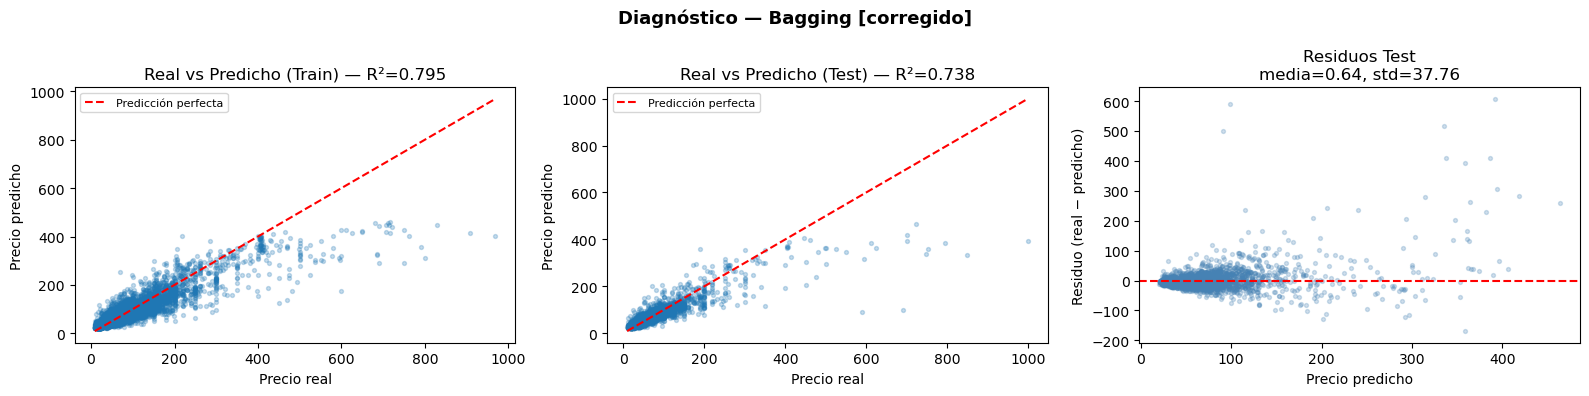

─────────────────────────────────────────────
>>> Corrigiendo GBM

    DIAGNÓSTICO:
    Gap de 0.1045 (R² train=0.9061,
    R² test=0.8016). En GBM el overfitting ocurre
    principalmente por dos razones: demasiados árboles (el modelo sigue
    aprendiendo ruido después del punto óptimo) y árboles demasiado
    complejos (max_depth alto).

    CAMBIOS APLICADOS Y RAZÓN DE CADA UNO:

    1. n_estimators = 1920 (iteración óptima de la curva de deviance)
       → La curva de deviance mostró que el RMSE en test alcanza su mínimo
         en la iteración 1920. Después de ese punto, añadir más árboles
         solo mejora el train pero empeora o estanca el test: el modelo
         empieza a ajustar el ruido específico del train.
         Usar exactamente 1920 árboles es el 'early stopping' manual.

    2. max_depth bajado de 3 a 2
       → En Boosting los árboles son pequeños por diseño (stumps de 2-5
         niveles). Bajar de 3 a 2 reduce la capacidad de cada árbol para
         capturar

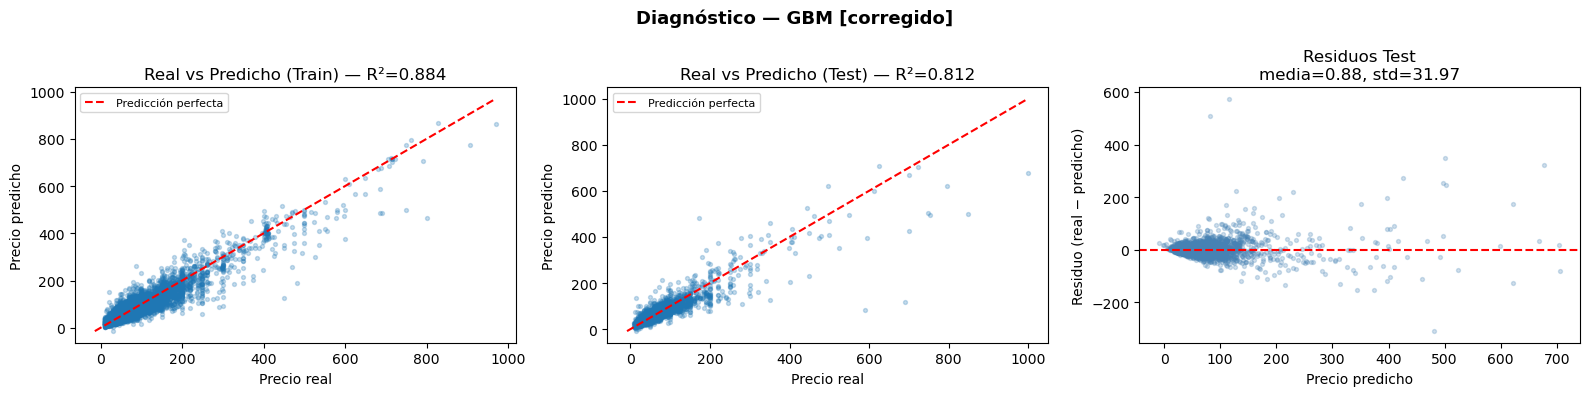

─────────────────────────────────────────────
>>> Corrigiendo XGBoost

    DIAGNÓSTICO:
    Gap de 0.1136 (R² train=0.8905,
    R² test=0.7769). XGBoost tiene la ventaja de
    ofrecer regularización nativa (L1 y L2) que en el modelo original
    no se activó, y early stopping que detiene el entrenamiento
    automáticamente en la iteración óptima.

    CAMBIOS APLICADOS Y RAZÓN DE CADA UNO:

    1. reg_alpha = 0.1  (regularización L1 sobre los pesos de las hojas)
       → Penaliza la suma de los valores absolutos de los pesos de cada
         hoja. Fuerza a que muchos pesos sean exactamente 0, eliminando
         splits que aportan poca información. Es la versión Lasso dentro
         del árbol: selección implícita de los splits más relevantes.

    2. reg_lambda = 2.0  (regularización L2 sobre los pesos de las hojas)
       → Penaliza la suma de los cuadrados de los pesos. Reduce todos
         los pesos suavemente sin llevarlos a 0 (como Ridge). Esto hace
         que el modelo no d

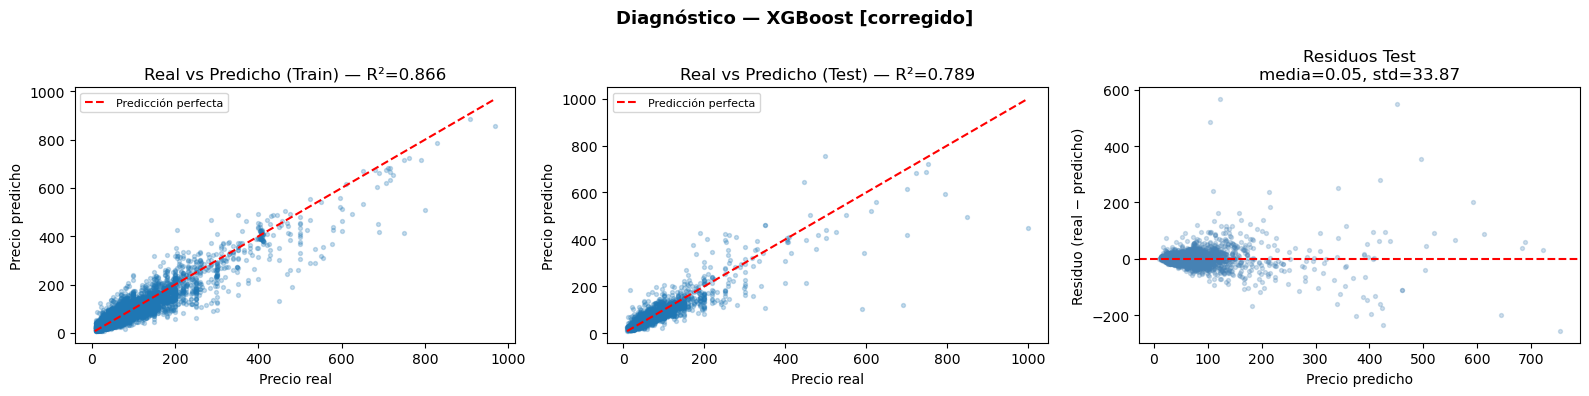

─────────────────────────────────────────────
>>> Corrigiendo SVR

    DIAGNÓSTICO:
    Gap de 0.1785 (R² train=0.8695,
    R² test=0.6910). En SVR el overfitting ocurre
    cuando el modelo intenta ajustar demasiado exactamente cada punto,
    en lugar de encontrar una función suave que capture la tendencia general.

    CAMBIOS APLICADOS Y RAZÓN DE CADA UNO:

    1. epsilon subido de 0.1 (default) a 1.0
       → epsilon define el 'tubo de tolerancia': predicciones dentro de
         ±epsilon del valor real NO se penalizan. Con epsilon=0.1 el modelo
         intenta ajustar cada punto con un error máximo de 0.1€, lo que
         lo obliga a memorizar incluso el ruido.
         Con epsilon=1.0, tolera errores de hasta 1€ sin penalización,
         permitiendo una función más suave que generaliza mejor.
         En datos de precios con RMSE ~40€, epsilon=0.1 es excesivamente
         preciso y fuerza memorización innecesaria.

    2. Rango de C reducido (máximo 100 en lugar de 1000)
   

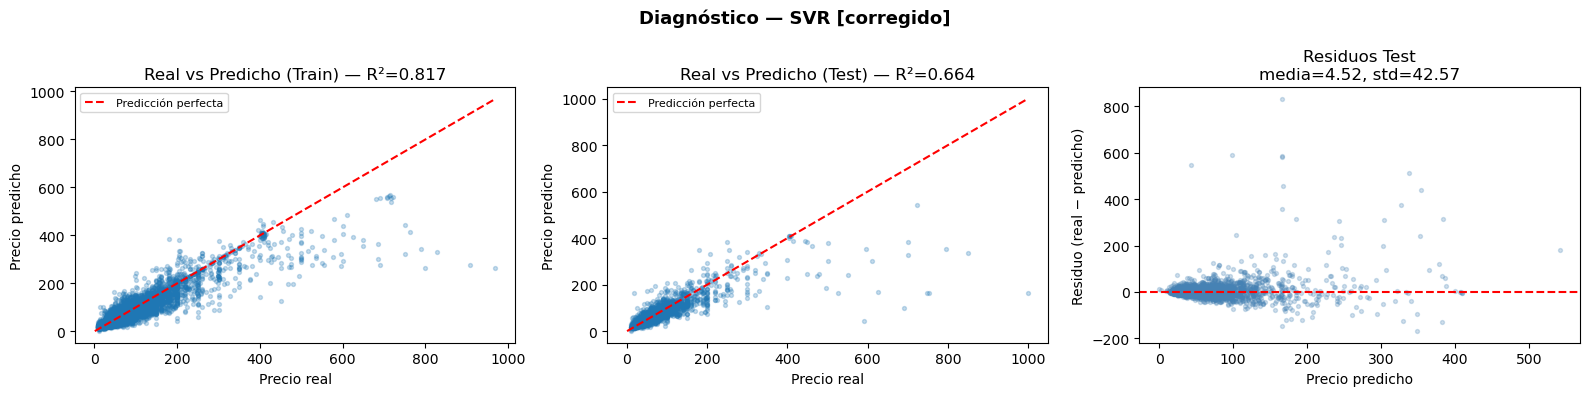


────────────────────────────────────────────────────
  COMPARATIVA: ORIGINAL vs CORREGIDO
────────────────────────────────────────────────────
 Modelo  R² orig  R² corr     ΔR²  Gap orig  Gap corr    ΔGap  RMSE orig  RMSE corr ΔRMSE
Bagging   0.8065   0.7381 -0.0683    0.1510    0.0574 -0.0936      32.47      37.76 +5.30
    GBM   0.8016   0.8122 +0.0106    0.1045    0.0716 -0.0329      32.88      31.98 -0.89
XGBoost   0.7769   0.7893 +0.0124    0.1136    0.0764 -0.0372      34.86      33.87 -0.98
    SVR   0.6910   0.6635 -0.0274    0.1785    0.1534 -0.0251      41.03      42.81 +1.78

  Cómo leer la tabla:
  · ΔR²  positivo → el modelo corregido predice MEJOR en test.
  · ΔGap negativo → el overfitting SE REDUJO tras la corrección.
  · ΔRMSE negativo → el error en euros BAJÓ tras la corrección.
  · Es posible que R² test baje ligeramente mientras el gap mejora:
    esto es un compromiso normal (menos memorización del train,
    más generalización robusta). Un gap bajo con R² test ra

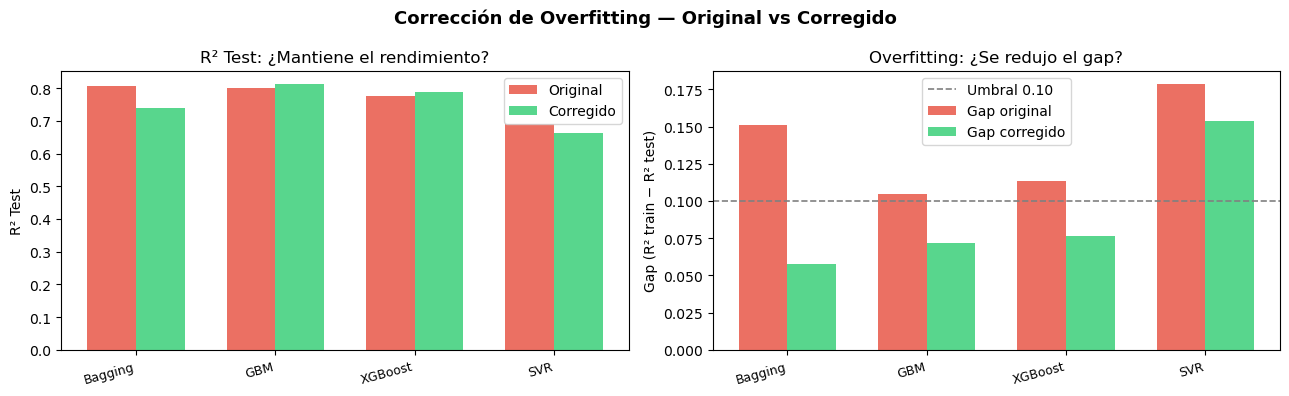


  Mejor modelo tras correcciones: GBM [corr]  (R²=0.8122)

  Análisis completado.
  Mejor modelo original: Bagging  (R²=0.8065, RMSE=32.47€)
  Modelos disponibles: lasso_, ridge_, tree_, rf_, bag_, gbm_, xgb_, svr_
  Versiones corregidas: bagging_c, gbm_c, xgboost_c, svr_c


In [6]:
%run modelos_regresion.py